# 이 기능은 DAU 얼마짜리 기능일까?

신규 기능의 **DAU**를 두 가지 즉각적인 지표 — **신규 유저 수**와 **D1 리텐션** — 만으로
예측해 봅니다. 핵심 아이디어는 신규 유저의 리텐션 커브를 **멱함수(power law)** `y = a·x^b` 로
모델링하고, 그 누적합을 하나의 상수로 압축해 다음 한 줄짜리 공식을 만드는 것입니다.

> **신규 피처 DAU = 신규 유저 수 × 신규 D1 리텐션 × (상수)**

이 노트북은 본문 이론의 **실습 1~3**을 코드로 구현합니다.
- **실습 1.** 서비스 전체 신규 유저의 리텐션 커브에서 상수 `b` 구하기 (`scipy.curve_fit`)
- **실습 2.** `b`를 하나의 상수로 단순화하기 (`x^b` 의 1년치 누적합)
- **실습 3.** 퀴즈에 적용하기 — 정답 공개 (도입 퀴즈의 기능 A·B에 공식 대입)

## 0. 실습용 데이터 준비

아래 셀은 의존성을 설치합니다. 그다음 데이터가 없다면
`python generate_data.py` 로 예시 데이터를 먼저 생성하세요
(리텐션 분석용 합성 예시 데이터입니다).

실습에는 아주 단순한 형태의 일별 활동 로그 하나면 충분합니다. 아래는 이번 실습에서 사용할
`data/active_daily.csv`의 일부입니다. 일별로 접속한 유저의 날짜(`date`)와 식별자(`user_id`),
그리고 단순한 플랫폼·국가 정보(`platform`, `country_code`)를 가지고 있습니다. 또한 `install_flag`
컬럼을 통해 해당 유저가 그날 설치를 한 유저인지 알 수 있습니다.

| date | user_id | platform | country_code | install_flag |
| --- | --- | --- | --- | --- |
| 2026-01-01 | u0009145 | android | US | TRUE |
| 2026-01-10 | u0009145 | android | US | FALSE |
| 2026-01-17 | u0009145 | android | US | FALSE |
| 2026-01-19 | u0009145 | android | US | FALSE |
| 2026-01-29 | u0009145 | android | US | FALSE |

In [1]:
# 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)
# %pip 매직은 현재 커널 환경에 설치하므로 PATH 문제 없이 동작합니다.
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import duckdb
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- 책 공통 차트 스타일 (팔레트·그리드·spine 통일) ---
PALETTE = ["#1f9d78", "#3b4556", "#d97706", "#6b7380"]  # green, slate, amber, muted
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.3,
    "figure.dpi": 150, "legend.frameon": False,
})

## 실습 1. 리텐션 커브에서 상수 `b` 구하기

앞서 이론에서 정리한 대로, 서비스 전체 신규 유저의 리텐션 커브를 활용하여 `b`를 구해 봅니다.
scipy의 `curve_fit`을 사용하여 전체 유저의 D1~D28 리텐션으로 `b`값을 추정한 뒤 평균값을 사용하는데,
아래 예시에서는 지난 3개월간 유입된 유저들의 D1~D28 리텐션을 사용하여 노이즈를 최대한 줄였습니다.
`curve_fit`은 주어진 데이터 점들에 가장 가깝게 지나가는 곡선의 계수를 찾아 주는 scipy 함수인데요,
D1~D28 리텐션 점들을 넣으면 이 점들과의 오차가 가장 작아지는 `a`와 `b`를 자동으로 계산해 줍니다.

먼저 서비스 전체 신규 유저의 **월별 D1~D28 리텐션 커브**를 구합니다.
아래 SQL 을 **DuckDB**로 예시 데이터(CSV)에 직접 실행합니다 — SQL 문법을 최대한 살리기 위해
DuckDB를 사용했지만, 실제 활용에서는 사용 중인 데이터 웨어하우스(DW)에 접근한다고 생각하시면 됩니다.
핵심 패턴은 설치 코호트(`installs`)와 전체 활동(`base`)을 같은 `user_id` 로
self-join 하여 `day_diff`(설치 후 경과일) 별 잔존율을 구하는 것입니다.

In [3]:
con = duckdb.connect()
con.execute("""
CREATE VIEW base AS
  SELECT date AS event_date, user_id, platform, install_flag
  FROM read_csv_auto('data/active_daily.csv');

-- 설치(=신규 유입) 이벤트만 추린다. basis_month 는 월별 코호트 버킷
CREATE VIEW installs AS
  SELECT event_date AS install_date, user_id, platform,
         DATE_TRUNC('month', event_date) AS basis_month
  FROM base
  WHERE install_flag = TRUE;
""")

등록해 둔 두 뷰(base·installs)를 self-join 해 월별·플랫폼별 D1~D28 리텐션 커브를 만듭니다.

In [4]:
query = """
-- 설치 유저(i)와 그 유저의 이후 방문(b)을 self-join -> 설치 후 day_diff 별 재방문 수
WITH daily_stat AS (
  SELECT i.basis_month, i.platform, i.install_date,
         DATE_DIFF('day', i.install_date, b.event_date) AS day_diff,
         COUNT(*) AS retained_users
  FROM installs AS i
  JOIN base AS b
    ON i.user_id = b.user_id AND b.event_date > i.install_date
  WHERE DATE_DIFF('day', i.install_date, b.event_date) BETWEEN 1 AND 28
  GROUP BY 1, 2, 3, 4
),
-- 코호트(설치일·플랫폼) 별 모수: 설치 유저 수
population AS (
  SELECT basis_month, platform, install_date, COUNT(DISTINCT user_id) AS total_user
  FROM installs
  GROUP BY 1, 2, 3
)
-- 코호트별 (잔존 수 / 모수)를 day_diff·플랫폼 기준으로 평균내어 리텐션 커브를 만든다
SELECT d.basis_month, d.platform, d.day_diff,
       AVG(d.retained_users / p.total_user) AS avg_retention
FROM daily_stat AS d
JOIN population AS p USING (basis_month, platform, install_date)
GROUP BY 1, 2, 3
ORDER BY 2, 1, 3
"""
df = con.execute(query).df()
print("rows:", len(df))
df.head()

rows: 168


,basis_month,platform,day_diff,avg_retention
0,2026-01-01,android,1,0.348728
1,2026-01-01,android,2,0.241854
2,2026-01-01,android,3,0.206545
3,2026-01-01,android,4,0.165124
4,2026-01-01,android,5,0.155179


이제 각 `(basis_month, platform)` 코호트의 D1~D28 리텐션에 power law
`func(x) = a · x^b` 를 `curve_fit` 으로 맞춰 `a`, `b` 를 추정합니다.
노이즈를 줄이기 위해 지난 3개월치 월 코호트를 각각 적합한 뒤 `b` 의 평균을 사용합니다.

In [5]:
def func(x, a, b):          # curve_fit 을 위한 power law
    return a * (x ** b)

days = np.arange(1, 29)     # D1 ~ D28
records = []
for (basis_month, platform), g in df.groupby(["basis_month", "platform"]):
    avg_retention = g.sort_values("day_diff")["avg_retention"].values
    popt, _ = curve_fit(func, days, avg_retention, maxfev=10000)
    records.append({"basis_month": basis_month, "platform": platform, "a": popt[0], "b": popt[1]})
df_constant = pd.DataFrame(records)

b_mean = df_constant["b"].mean()
for tag, sub in [("Total", df_constant),
                 ("iOS", df_constant[df_constant.platform == "ios"]),
                 ("Android", df_constant[df_constant.platform == "android"])]:
    print(f"{tag:8s} b mean : {round(sub['b'].mean(), 4)}")
df_constant

Total    b mean : -0.4804
iOS      b mean : -0.4603
Android  b mean : -0.5005


,basis_month,platform,a,b
0,2026-01-01,android,0.346585,-0.500278
1,2026-01-01,ios,0.426724,-0.459826
2,2026-02-01,android,0.351073,-0.504254
3,2026-02-01,ios,0.425190,-0.454759
4,2026-03-01,android,0.351179,-0.496916
5,2026-03-01,ios,0.435590,-0.466187


### 실측 리텐션 vs 두 가지 모델

power law(`y = a·x^b`)는 0 이상의 값으로 **수렴**하는 반면,
등비급수(`y = a^x`)는 빠르게 0으로 **붕괴**합니다. 바로 이 차이가 Carrying Capacity
공식이 잔존 유저를 과소평가하는 이유입니다.

적합이 잘 됐는지 확인해 봅니다. 플랫폼별 실측 리텐션(점) 위에 멱함수 모델(초록 실선)과, 본문에서 비교했던 등비급수 모델(회색 점선)을 겹쳐 그리면 60일까지의 차이가 한눈에 보입니다.
예시 데이터에서는 `b`의 평균이 약 **-0.48**, iOS는 **-0.46**, Android는 **-0.50**이 나옵니다.

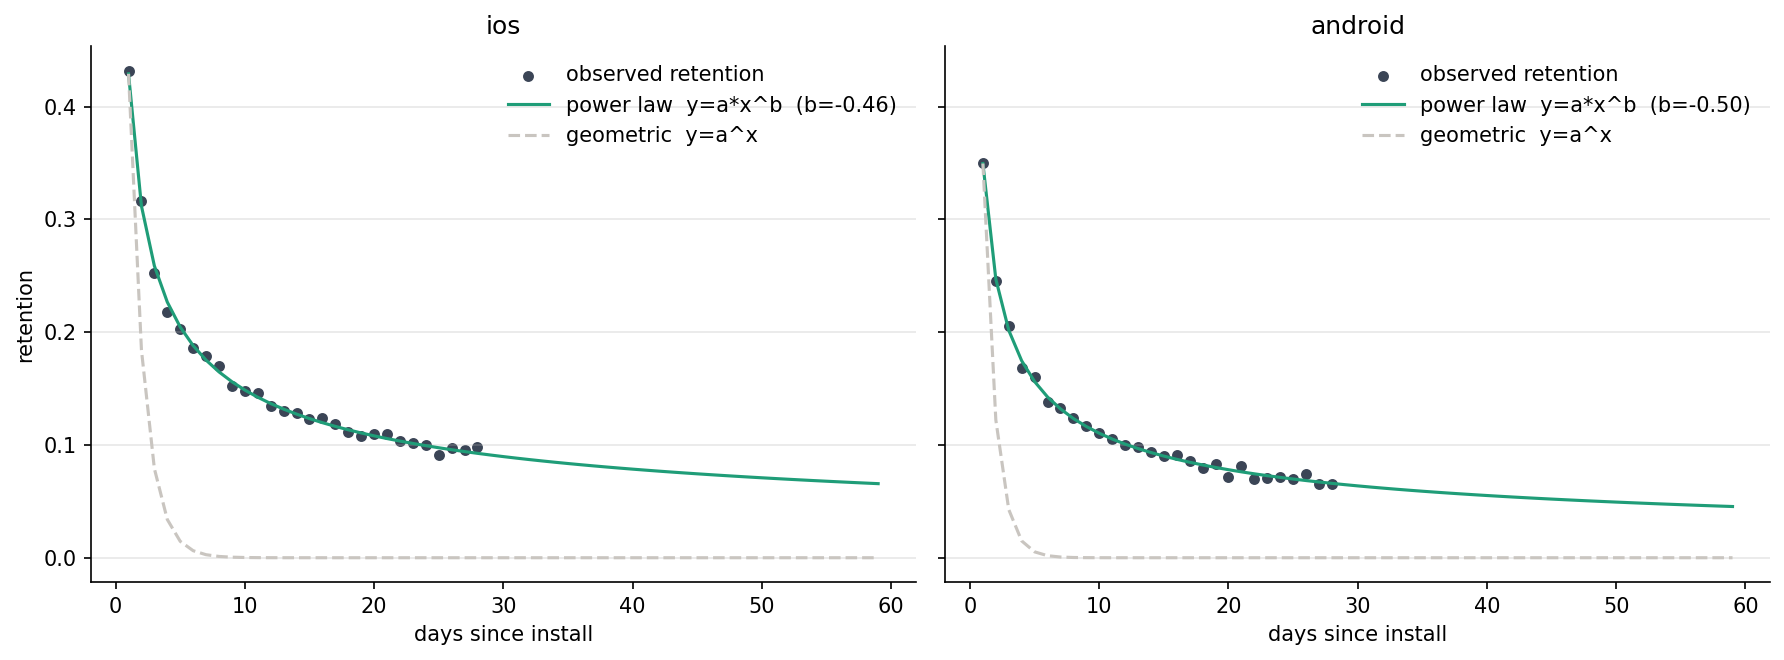

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x_full = np.arange(1, 60)
for ax, platform in zip(axes, ["ios", "android"]):
    observed = df[df.platform == platform].groupby("day_diff")["avg_retention"].mean()
    a_p = df_constant.loc[df_constant.platform == platform, "a"].mean()
    b_p = df_constant.loc[df_constant.platform == platform, "b"].mean()
    ax.scatter(observed.index, observed.values, s=18, color="#3b4556", label="observed retention")
    ax.plot(x_full, func(x_full, a_p, b_p), color="#1f9d78", label=f"power law  y=a*x^b  (b={b_p:.2f})")
    ax.plot(x_full, a_p ** x_full, "--", color="#c9c5c0", label="geometric  y=a^x")
    ax.set_title(platform); ax.set_xlabel("days since install"); ax.legend()
axes[0].set_ylabel("retention")
plt.tight_layout(); plt.show()

## 실습 2. `b`를 하나의 상수로 단순화하기

전체 유저 수는 다음과 같이 정리됩니다.

```
오늘 전체 유저 수 = 신규유저수 × ( y(0) + y(1) + ... + y(N) )
                = 신규유저수 × a × ( 0^b + 1^b + 2^b + ... + N^b )
```

여기서 `a` 는 곡선의 시작점이므로 **신규 D1 리텐션**으로 두고,
나머지 `( 0^b + 1^b + ... + N^b )` 를 1년(365일)으로 가정해 하나의 상수로 만듭니다.
`0^b` 항은 설치 당일(D0, 모두 활성)이므로 **1** 로 둡니다.

In [7]:
# x=0 (설치 당일) 항은 1.0, 나머지는 x^b_mean 의 1년치 누적합
x = np.arange(1, 365)
baseline = 1.0 + np.sum(x ** b_mean)

print(f"b_mean   = {b_mean:.4f}")
print(f"baseline = {baseline:.1f}   (= 0^b 항(=1) + sum of x^b for x=1..364)")

b_mean   = -0.4804
baseline = 40.9   (= 0^b 항(=1) + sum of x^b for x=1..364)


이제 복잡한 누적합 대신 **하나의 상수**로 공식을 쓸 수 있습니다.

> **신규 피처 DAU = 신규 유저 수 × 신규 D1 리텐션 × baseline**

이 상수는 서비스의 리텐션 커브(`b`)에 따라 달라지는데요. 이번 예시 데이터에서는 약 **41**이 나오고,
도입 퀴즈의 기능 A·B가 속한 예시 서비스에서는 약 **63**이었습니다. 같은 공식이라도 `b`가 어떻게
나오느냐에 따라 상수가 달라지므로, 우리 서비스의 리텐션 커브로 한 번 구해 두고 쓰시는 것을 권합니다.

한 가지 짚어둘 점은, 등비급수와 달리 `x^b`의 누적합은 수렴값이 없기 때문에 기간을 늘리면 상수가
더 커진다는 점입니다. 물론 시간이 지날수록 리텐션이 낮아지기 때문에 이 누적합 차이도 뒤로 갈수록
크게 늘어나지 않긴 한데요. 그럼에도 명확한 소통을 위해서는 첫 공유 시점에 "1년 시점의 기대 DAU"와
같이 기준 기간을 함께 이야기하는 것이 좋습니다.

## 실습 3. 퀴즈에 적용하기 — 정답 공개

도입 퀴즈의 예시 서비스 상수 63을 최종 공식에 넣어 보면 다음과 같습니다.

| Feature | 신규 유저 수 | D1 리텐션 | 예측 DAU | 실제 DAU |
| --- | --- | --- | --- | --- |
| A | 6,700 | 7% | ≈29,500 | 26,943 |
| B | 600 | 35% | ≈13,200 | 13,000 |

기능 A는 6,700 × 7% × 63 ≈ 29,500, 기능 B는 600 × 35% × 63 ≈ 13,200이 나오는데요.
신규 유저는 적지만 리텐션이 높은 B가 아니라, 유입이 큰 A가 더 큰 DAU로 수렴한다는 게 도입 퀴즈의 답입니다.
물론 이 공식 또한 여러 가정이 있기에 정확한 수치를 예측할 수는 없지만, 우리 서비스에서 출시된 기능의
DAU가 1만이 될지, 5만이 될지, 10만이 될지 쉽게 가늠해 볼 수 있고, 어떤 레버를 얼마만큼 올려야
원하는 DAU를 달성할 수 있을지도 판단이 쉬워집니다.